## This miniproject will show some experiment with MCMC and Linear Regression 

In [13]:
import pandas as pd 
import numpy as np
import scipy
import matplotlib.pyplot as plt 

### Part 1: Experiment when scaling a pdf function by a constant 

In [14]:
import copy 
from tqdm import trange

# The code below implement MCMC with Metropolis-Hasting algorithm for the next state transition

class AcceptanceTracker(object):
    def __init__(self):
        self.__accept_count = 0
        self.__total_count = 0 

    def record(self, cur_state, next_state):
        if cur_state is not next_state: 
            self.__accept_count += 1

        self.__total_count += 1 

    def reset(self):
        self.__accept_count = 0
        self.__total_count = 0 

    def get_acceptance_rate(self):
        return self.__accept_count / self.__total_count 


def mcmc(initial_state, log_pdf_fn, proposed_fn, iters = 10000, tracker = None):
    state_list = [initial_state]
    reject_count = 0 
    for _ in trange(iters):
        cur_state = state_list[-1] 
        proposed_state = proposed_fn(cur_state)
        log_diff = min(log_pdf_fn(proposed_state) - log_pdf_fn(cur_state), 0)
        next_state = proposed_state if (log_diff > np.log(np.random.uniform(0, 1))) else cur_state 
        if tracker: 
            tracker.record(cur_state, next_state)
        
        state_list.append(copy.deepcopy(next_state))

    return state_list 

  0%|                                         | 0/10000 [00:00<?, ?it/s]/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_99690/2703685755.py:31: RuntimeWarning: invalid value encountered in scalar subtract
  log_diff = min(log_pdf_fn(proposed_state) - log_pdf_fn(cur_state), 0)
100%|██████████████████████████| 10000/10000 [00:00<00:00, 14601.80it/s]
/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_99690/870439038.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


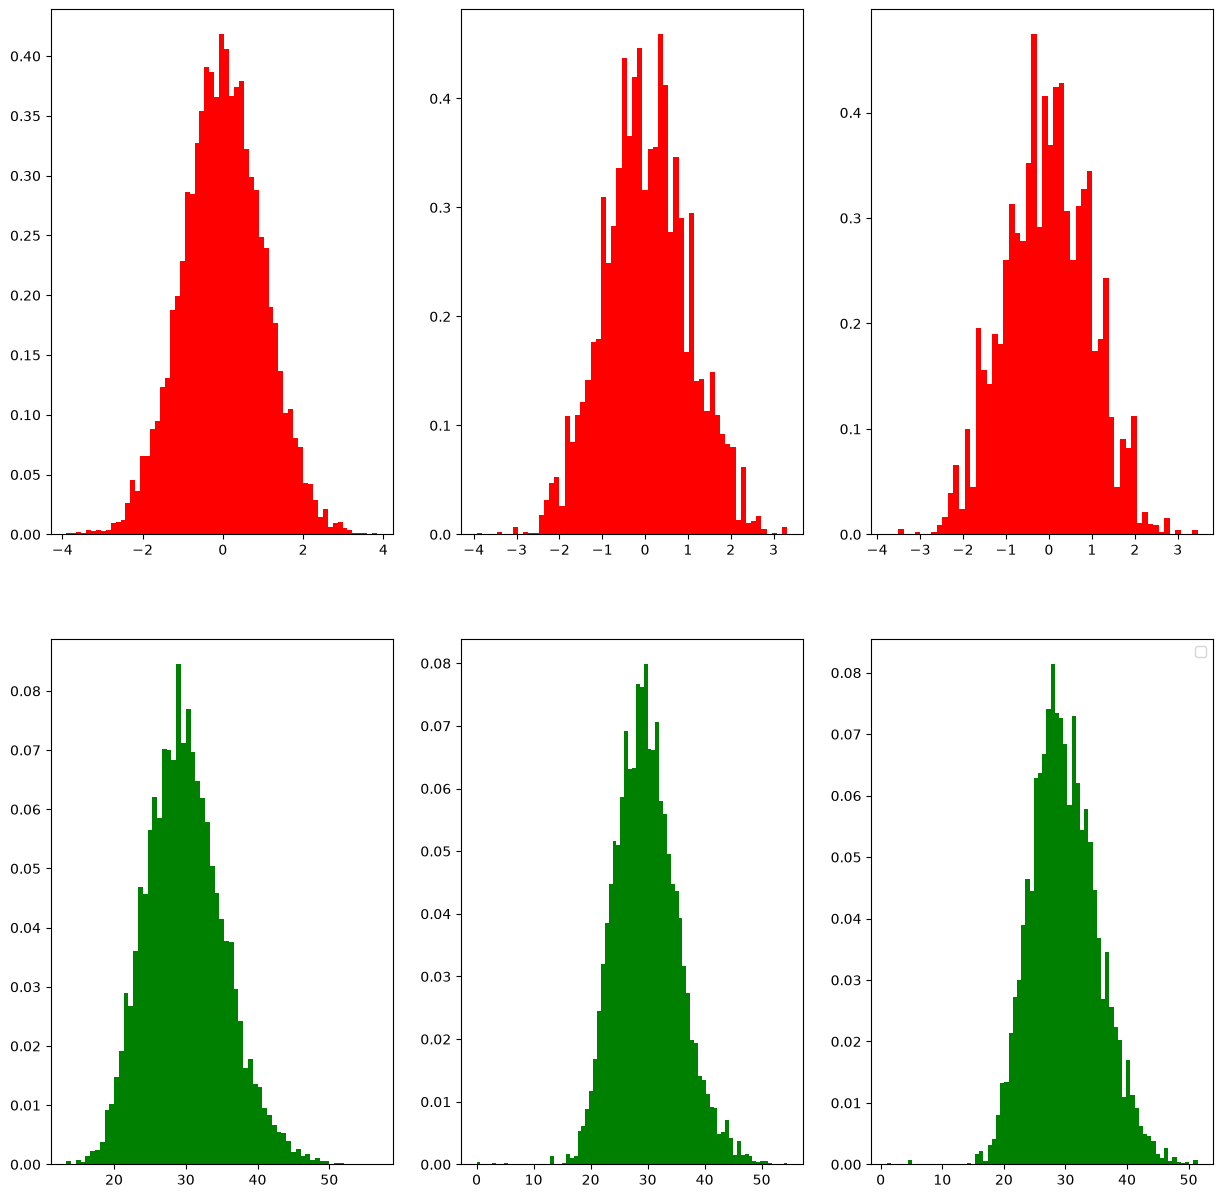

In [15]:
from functools import partial

distribs = [
    scipy.stats.norm(loc = 0, scale = 1), 
    scipy.stats.gamma(a = 30), 
] 

z0, z1, size, scale_lambda = 0, 1, 10000, 2 

def proposed_fn(z):
    return z + np.random.normal() * 10  

def scale_log_fn(fn, x): 
    return np.log(scale_lambda) + fn(x)

colors = ['red', 'green', 'blue']
fig, axes = plt.subplots(len(distribs), 3, squeeze=False, figsize = (15, 15))
for i in range(len(distribs)):
    axes[i, 0].hist(distribs[i].rvs(size = size), bins = 'auto', density = True, color = colors[i])
    axes[i, 1].hist(mcmc(z0, distribs[i].logpdf, proposed_fn, iters = size), bins = 'auto', density = True, color = colors[i]) 
    axes[i, 2].hist(mcmc(z1, partial(scale_log_fn, distribs[i].logpdf), proposed_fn, iters = size), bins = 'auto', density = True, color = colors[i]) 
    
plt.legend()
plt.show()

### Part 2: Tracking a position in 2D space 

The problem is to track the location distibution of a point in 2D array with 3 radars measure the Euclidean to the truth position
with some predefined deviation. 

Define $gamma$ as the posterior distribution of the point location after incoporate with radars measurement:  

$
   gamma(state) \propto prior(state) * \prod_1^3 p({measure_i} | {state})
$

with subtle assumption that each measure is independent for all radars. 

As the measure for radar_i has deviation sd, it means that ${measure_i}$ ~ $ N({measure_i}, ||radar_i - state|| , sd_i ^ 2)$ 

We could use this gamma function as the function used ratio for state transitioning.  

In [16]:
import math 
from scipy import stats 

def proposed_state(state):
    return state + np.random.normal(0, scale = move_sigmas)

# let start with gamma with no prior 
def gamma_pdf_fn(state, radar_measures): 
    log_sum = 0 
    state_measures = np.linalg.norm(radar_locs - state, axis = 1) 
    for radar_id in range(len(radar_measures)):
        log_sum += stats.norm(
            loc = state_measures[radar_id], 
            scale = radar_sigmas[radar_id]
        ).logpdf(radar_measures[radar_id])
    
    return log_sum 



In [17]:
# set up
# unknown to us 
pos_truth = np.array([1,1]) 

# radar positions
radar_locs = [
    np.array([0, 0]), 
    np.array([10, 10]), 
    np.array([6, 3])
]

# the deviations of the measurements for each radars 
radar_sigmas = np.array([
    0.5, 
    0.1, 
    0.1 
])

# move sigma 
move_sigmas = np.array(
    [
        0.6, 
        0.3
    ]
)

### Set up radar measures and running MCMC 

In [18]:
from functools import partial 

initial_state = np.array([2, 4])

# measure by radar with noise 
radar_measures = np.linalg.norm(radar_locs - pos_truth, axis=1) + np.random.normal(loc = 0, scale = radar_sigmas)
print("radars measure: ", radar_measures)

tracker = AcceptanceTracker() 
state_list = mcmc(initial_state, partial(gamma_pdf_fn, radar_measures = radar_measures), proposed_state, 20000, tracker)
print("acceptance rate: {}".format(tracker.get_acceptance_rate()))

radars measure:  [ 1.75664819 12.54083096  5.35232425]


100%|████████████████████████████| 20000/20000 [00:31<00:00, 636.30it/s]

acceptance rate: 0.1316


### Plot x and y distributions

/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_99690/2286343919.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


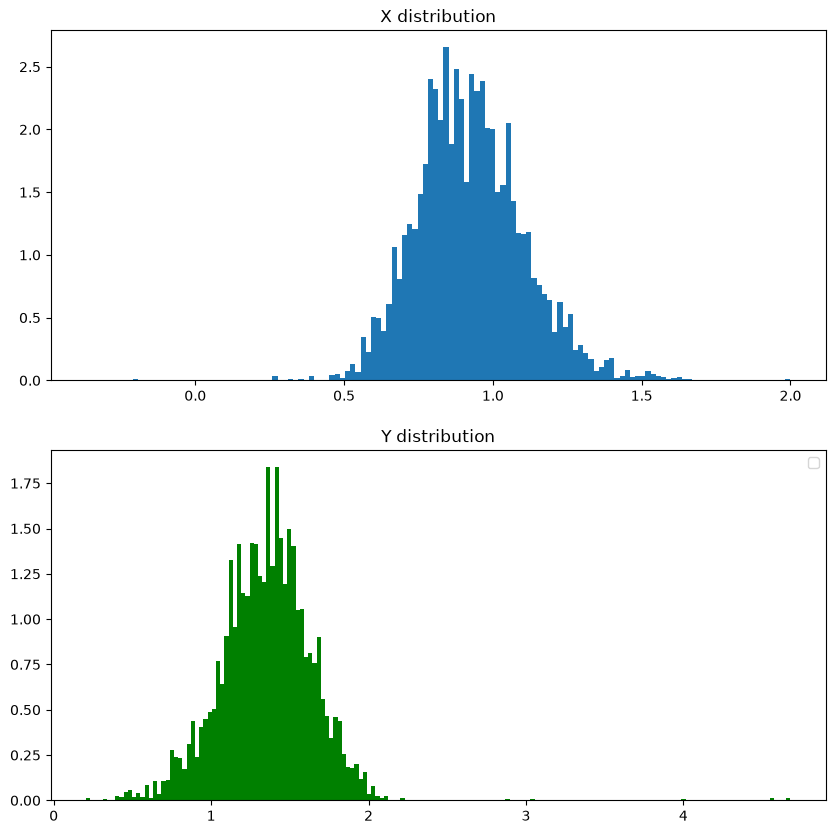

In [19]:
fig, ax = plt.subplots(2, 1, figsize = (10,10))
x = [state[0] for state in state_list]
y = [state[1] for state in state_list]

ax[0].hist(x, density = True, bins = 'auto')
ax[0].set_title("X distribution")

ax[1].hist(y, density = True, bins = 'auto', color = 'green')
ax[1].set_title("Y distribution")

plt.legend()
plt.show()

### Trace Plot 


/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_99690/3149738548.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


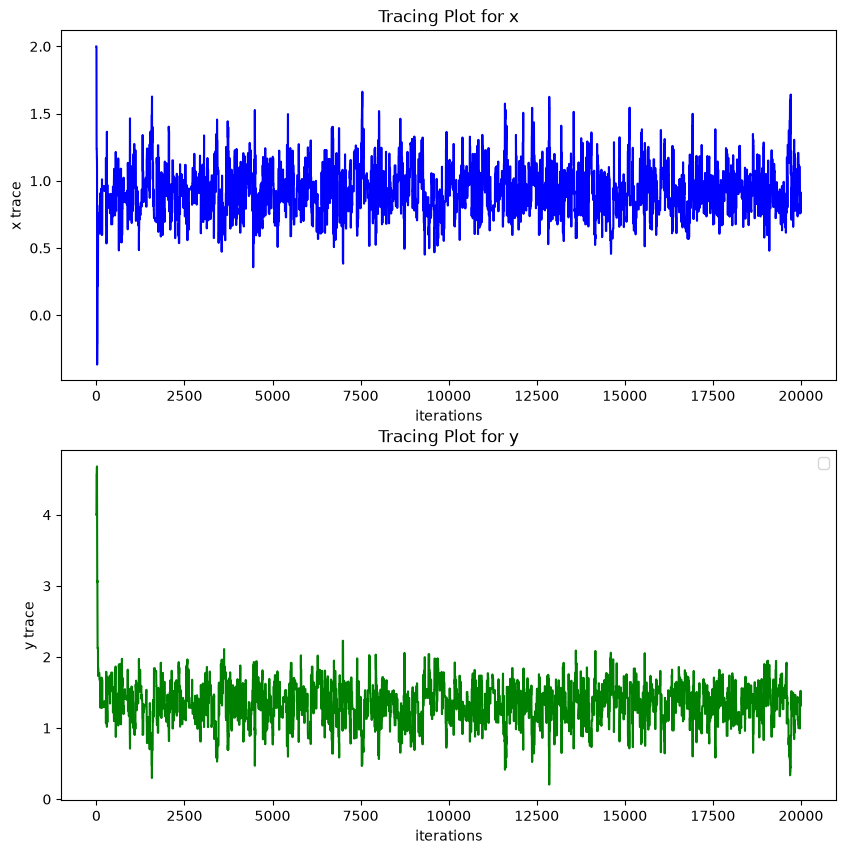

In [20]:
fig, ax = plt.subplots(2, 1, figsize = (10, 10)) 

sample_interval = 1
iters = [_ for _ in range(0, len(state_list), sample_interval)]
sample_x_list = [state_list[i][0] for i in range(0, len(state_list), sample_interval)]
sample_y_list = [state_list[i][1] for i in range(0, len(state_list), sample_interval)]

ax[0].plot(iters, sample_x_list, color = 'blue')
ax[0].set_xlabel("iterations")
ax[0].set_ylabel("x trace")
ax[0].set_title("Tracing Plot for x")

ax[1].plot(iters, sample_y_list, color = 'green')
ax[1].set_xlabel("iterations")
ax[1].set_ylabel("y trace")
ax[1].set_title("Tracing Plot for y")

plt.legend()
plt.show()

#### TODO 
[x] Experiment with predefined prior for the state. Currently there is no "prior" 

[x] Tracking acceptance rate track and experiment with higher move_sigmas. 

[x] MCMC trace plot. 

## Simulated Tempering 

A method that is helping with sampling a posterior distribution which has multiple modes by constructing a list of intermediate distributions $\pi_0, \pi_1, ... \pi_T$, applying the MCMC for each pair of distributions, 

### Problem with MCMC

- Given a pdf function:
$p(x) = 0.5 N(x; -5, 1) + 0.5 N(x; 5; 1)$

- Let's first visualize its pdf function.

    - As could be seen below, there are 2 modes for the distributions  

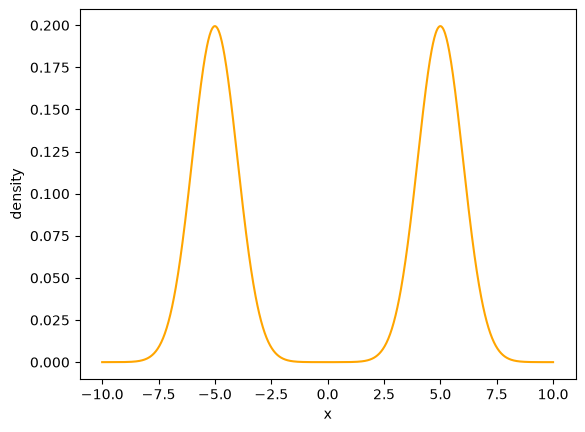

In [21]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns 

def pi_1_log_pdf(x):
    dist_0 = norm(loc = -5, scale = 1) 
    dist_1 = norm(loc = 5, scale = 1) 
    return np.logaddexp(
        np.log(0.5) + dist_0.logpdf(x), 
        np.log(0.5) + dist_1.logpdf(x),  
    )

x = np.linspace(-10, 10, 1000)
y = pi_1_log_pdf(x)

fig, ax =  plt.subplots()
ax.plot(x, np.exp(y), color = 'orange')
ax.set_xlabel("x")
ax.set_ylabel("density")
plt.show()

Now let's try to use normal MCMC methods to see how our sample looks like.

Let's start with z0 = 1. 

In [22]:
def proposed_fn(z):
    return z + np.random.normal()

z0, iters = 1, 20000 
tracker = AcceptanceTracker()
z_list = mcmc(z0, pi_1_log_pdf, proposed_fn, iters, tracker)
print("Acceptance rate: {}".format(tracker.get_acceptance_rate()))

100%|████████████████████████████| 20000/20000 [00:20<00:00, 980.97it/s]

Acceptance rate: 0.7056


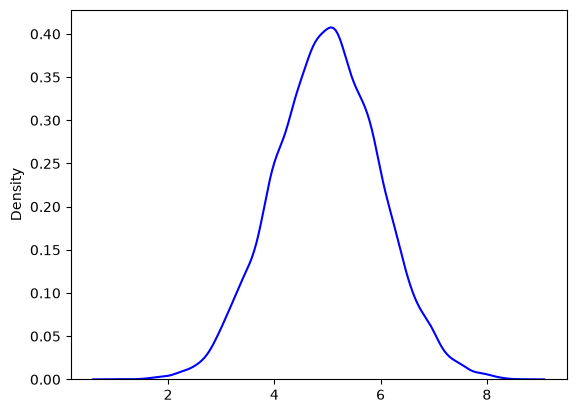

In [23]:
fig, ax =  plt.subplots()
sns.kdeplot(z_list, color = 'blue', ax = ax)
plt.show()

As could be seen, it seems that only the mode center around 5 is discovered. The other mode failed to be seen from our MCMC

Now let's try with the simulated tempering algorithm. 

In [24]:
from tqdm import trange
import numpy as np
import copy

class SimulatedTempering(object):
    def __init__(self, target_dist, target_sample, proposed_fn):
        # with the first dist is the target distrib, 
        # last dist is the initial distrib
        # store the logpdf func of the distribs 
        self._inter_dists = [target_dist]
        self._inter_samples = [ [target_sample] ]
        self._proposed_fn = proposed_fn 
        self._acc_trackers = [AcceptanceTracker()]

    def add_intermediate_dist(self, dist, dist_sample):
        self._inter_dists.append(dist)
        self._inter_samples.append([dist_sample])
        self._acc_trackers.append(AcceptanceTracker())

    def run(self, iters = 10000):
        for iter in trange(iters):
            for i in range(len(self._inter_dists) - 1, 0, -1):
                # mcmc for both i-1, i distribs 
                dist_i, dist_j = self._inter_dists[i], self._inter_dists[i-1]
                z_i_old, z_j_old = self._inter_samples[i][-1], self._inter_samples[i-1][-1]
                z_i_proposed, z_j_proposed = self._proposed_fn(z_i_old), self._proposed_fn(z_j_old)
                
                z_i_new = z_i_proposed if (np.log(np.random.uniform()) < min(0, dist_i(z_i_proposed) - dist_i(z_i_old))) else z_i_old
                z_j_new = z_j_proposed if (np.log(np.random.uniform()) < min(0, dist_j(z_j_proposed) - dist_j(z_j_old))) else z_j_old
                tracker_i, tracker_j = self._acc_trackers[i], self._acc_trackers[i-1]
                # track mcmc acceptance records 
                tracker_i.record(z_i_old, z_i_new)
                tracker_j.record(z_j_old, z_j_new)
                
                # add to the sample lists anyway 
                self._inter_samples[i].append(copy.deepcopy(z_i_new))
                self._inter_samples[i-1].append(copy.deepcopy(z_j_new))
                    
                # swap between 2 distribs and add again
                log_ratio_new = dist_i(z_j_new) + dist_j(z_i_new)
                log_ratio_old = dist_i(z_i_new) + dist_j(z_j_new)
                if np.log(np.random.uniform()) < min(log_ratio_new - log_ratio_old, 0): 
                    z_i_new, z_j_new = z_j_new, z_i_new
                
                self._inter_samples[i].append(copy.deepcopy(z_i_new))
                self._inter_samples[i-1].append(copy.deepcopy(z_j_new))    
    
    def get_start_samples(self):
        return copy.deepcopy(self._inter_samples[-1])

    def get_inter_samples(self, i):
        return copy.deepcopy(self._inter_samples[i])
    
    def get_target_samples(self):
        return copy.deepcopy(self._inter_samples[0])

Now try to see if our ST could help discover the other modes. 
In our experiment here we only experiment with a single intermediate distributions besides the target distribution. 
For sake of simplicity we choose normal distribution 

In [25]:
from scipy.stats import norm 

def proposed_fn(z):
    return z + np.random.normal(loc = 0, scale = 1)

solver = SimulatedTempering(
    pi_1_log_pdf, 
    z0, 
    proposed_fn
)

solver.add_intermediate_dist(
    norm(loc = 0, scale = 5.0).logpdf, 
    1
)

In [26]:
def run_experiment(solver, distrib_len = 2, iters = 10000): 
    solver.run(iters = iters)
    fig, ax =  plt.subplots()
    for i in range(distrib_len): 
        sample_list = solver.get_inter_samples(i)
        label = 'target' if i == 0 else str(i) 
        sns.kdeplot(sample_list, ax = ax, label = label)
    
    ax.plot(x, np.exp(pi_1_log_pdf(x)), color = 'orange', label = 'unknown target')
    
    plt.legend() 
    plt.show()

100%|██████████████████████████████| 1000/1000 [00:02<00:00, 444.33it/s]


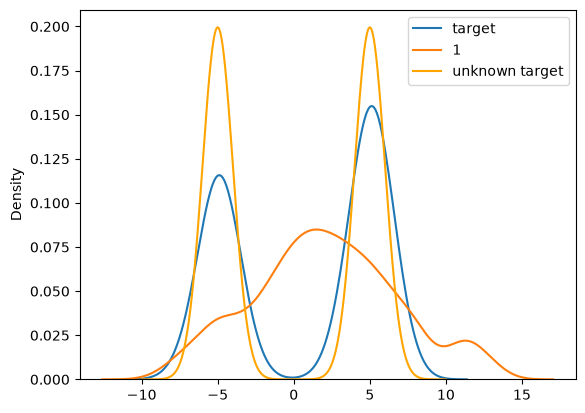

In [27]:
run_experiment(solver, iters = 1000)

As could be seen, now 2 modes has been discovered, however, our sample target is not exactly matched the generated one. This is due to the fact that it is hard to one step jump from Gaussian to our target one. Let's try adding intermediates and rerun our experiment

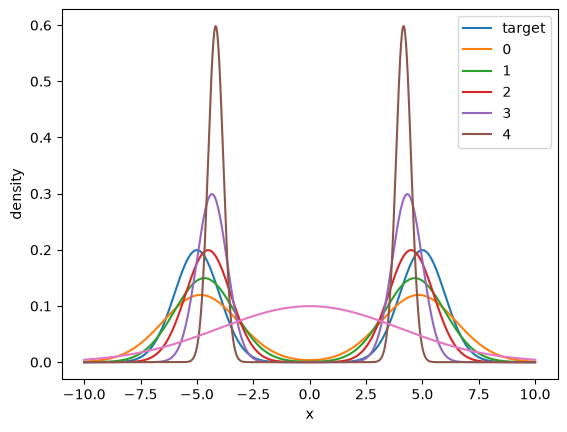

In [28]:
def pi_2_log_pdf(x, loc, scale):
    dist_0 = norm(loc = loc, scale = scale) 
    dist_1 = norm(loc = -loc, scale = scale) 
    return np.logaddexp(
        np.log(0.5) + dist_0.logpdf(x), 
        np.log(0.5) + dist_1.logpdf(x),  
    )

import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns 

x = np.linspace(-10, 10, 1000)

fig, ax =  plt.subplots()
ax.plot(x, np.exp(pi_1_log_pdf(x)), label = 'target')
for i in range(5):
    loc = 5 - (6 - 5) / 6 * (i + 1)
    scale = 2 - (3 - 1) / 6 * (i + 1)
    _y = pi_2_log_pdf(x, loc, scale)
    ax.plot(x, np.exp(_y), label = str(i))

ax.plot(x, np.exp(norm(loc = 0, scale = 4).logpdf(x)))
ax.set_xlabel("x")
ax.set_ylabel("density")

plt.legend()
plt.show()

100%|███████████████████████████████| 1000/1000 [00:22<00:00, 44.64it/s]


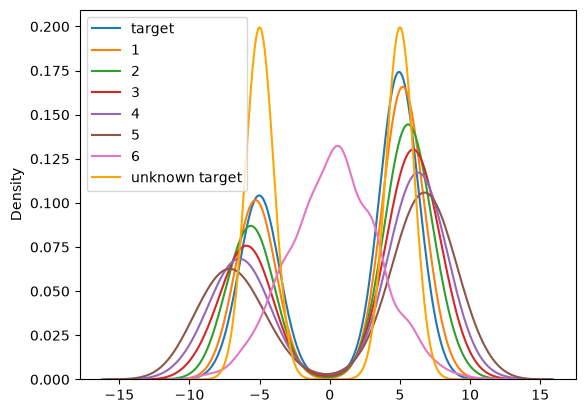

In [29]:
from functools import partial 
from scipy import stats 

solver = SimulatedTempering(
    pi_1_log_pdf, 
    z0, 
    proposed_fn
)

for i in range(5):
    loc = 5 + (7 - 5) / 6 * (i + 1) 
    scale = 1 + (2 - 1) / 6 * (i + 1)
    solver.add_intermediate_dist(
        partial(pi_2_log_pdf, loc = loc, scale = scale), 
        1
    )

solver.add_intermediate_dist(
    stats.norm(loc = 0, scale = 3).logpdf, 
    1
)

run_experiment(solver, distrib_len = 7, iters = 1000)

### Application with 2D radar tracking

- Now for tracking a 2D point in a plane, instead of 3 radars, we now only use 2 radars so that the set of (x, y) will be located in 2 clusters. 

In [30]:
from scipy import stats
# try with some set up first

# set up
# unknown to us 
pos_truth = np.array([2,0]) 

# radar positions
radar_locs = [
    np.array([0, 0]), 
    np.array([4, 4])
]

# the deviations of the measurements for each radars 
radar_sigmas = np.array([
    0.1, 
    0.1, 
])

# move sigma 
move_sigmas = np.array(
    [
        0.5, 
        0.5, 
    ]
)

# set up a prior on the location of the location
prior = stats.multivariate_normal(mean=[2, 2], cov=[[1, 0], [0, 1]])

In [31]:
# measure by radar with noise 
radar_measures = np.linalg.norm(radar_locs - pos_truth, axis=1) + np.random.normal(loc = 0, scale = radar_sigmas)
print("radars measure: ", radar_measures)

radars measure:  [2.01442395 4.54029676]


In [32]:
def proposed_state(state):
    return state + np.random.normal(0, scale = move_sigmas)

# let start with gamma with no prior 
def gamma_pdf_fn(state, prior, radar_measures): 
    log_sum = 0 if not prior else prior.logpdf(state)
    state_measures = np.linalg.norm(radar_locs - state, axis = 1) 
    for radar_id in range(len(radar_measures)):
        log_sum += stats.norm(
            loc = state_measures[radar_id], 
            scale = radar_sigmas[radar_id]
        ).logpdf(radar_measures[radar_id])
    
    return log_sum 


In [33]:
from functools import partial 
from scipy import stats

#target_dist, target_sample, proposed_fn

solver = SimulatedTempering(
    partial(gamma_pdf_fn, prior = prior, radar_measures = radar_measures), 
    np.array([4, 4]), 
    proposed_state
)

solver.add_intermediate_dist(
    stats.multivariate_normal(mean=[0, 0], cov=[[1, 0], [0, 1]]).logpdf, 
    np.array([1, 1]), 
)

solver.run(iters = 10000)

100%|████████████████████████████| 10000/10000 [00:21<00:00, 454.96it/s]


In [34]:
start_samples = solver.get_start_samples()
target_samples = solver.get_target_samples()

sample_interval = 1
iters = [_ for _ in range(0, len(target_samples), sample_interval)]

sample_target_x_list = [target_samples[i][0] for i in range(0, len(target_samples), sample_interval)]
sample_target_y_list = [target_samples[i][1] for i in range(0, len(target_samples), sample_interval)]

sample_start_x_list = [start_samples[i][0] for i in range(0, len(start_samples), sample_interval)]
sample_start_y_list = [start_samples[i][1] for i in range(0, len(start_samples), sample_interval)]

### Histogram Plot

- Can see if the sample resembles the desired distributions

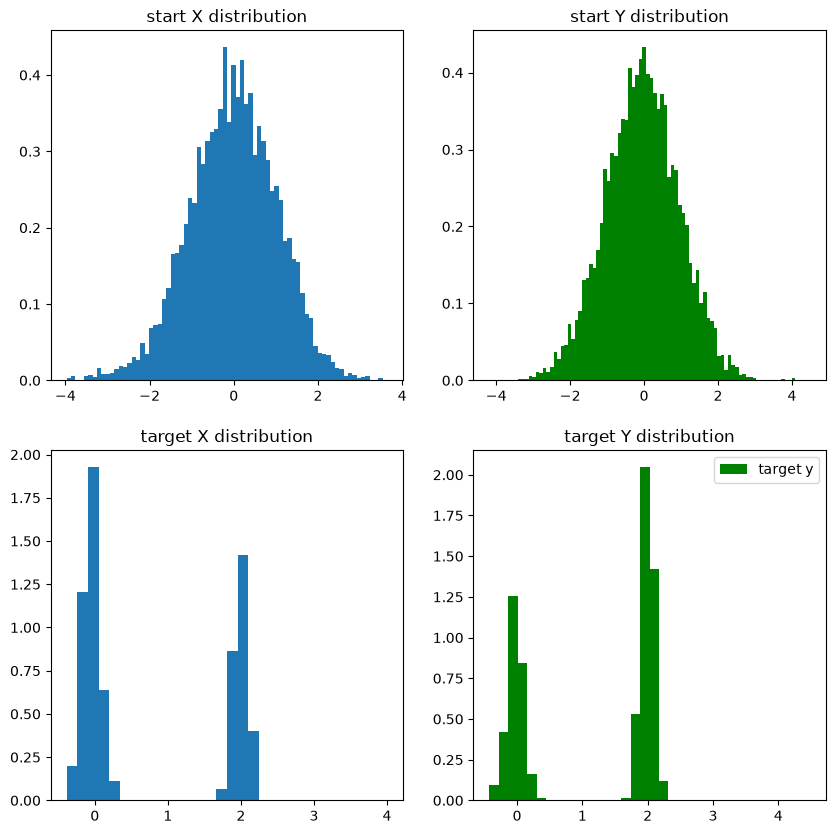

In [35]:
fig, ax = plt.subplots(2, 2, figsize = (10,10))

ax[0, 0].hist(sample_start_x_list, density = True, bins = 'auto', label = 'start x')
ax[0, 0].set_title("start X distribution")

ax[0, 1].hist(sample_start_y_list, density = True, bins = 'auto', color = 'green', label = 'start y')
ax[0, 1].set_title("start Y distribution")

ax[1, 0].hist(sample_target_x_list, density = True, bins = 'auto', label = 'target x')
ax[1, 0].set_title("target X distribution")

ax[1, 1].hist(sample_target_y_list, density = True, bins = 'auto', color = 'green', label = 'target y')
ax[1, 1].set_title("target Y distribution")

plt.legend()
plt.show()

### Trace Plot

- Can see if the reject rate is high by those horizontal move

/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_99690/1639072088.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


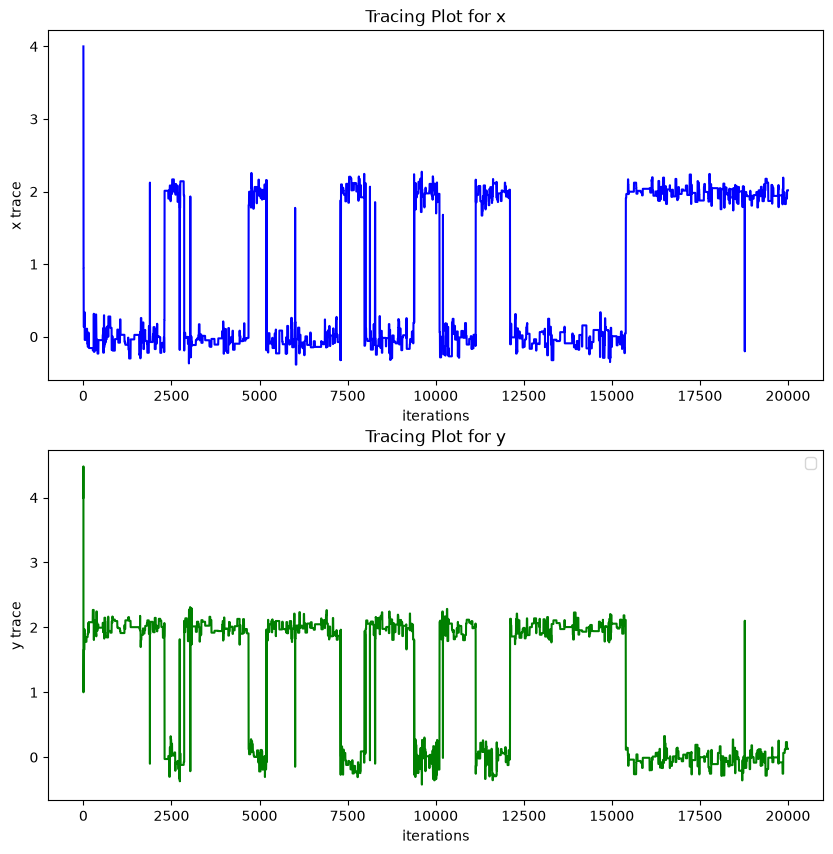

In [36]:
fig, ax = plt.subplots(2, 1, figsize = (10, 10)) 

ax[0].plot(iters, sample_target_x_list, color = 'blue')
ax[0].set_xlabel("iterations")
ax[0].set_ylabel("x trace")
ax[0].set_title("Tracing Plot for x")

ax[1].plot(iters, sample_target_y_list, color = 'green')
ax[1].set_xlabel("iterations")
ax[1].set_ylabel("y trace")
ax[1].set_title("Tracing Plot for y")

plt.legend()
plt.show()

TODO:

[x] Investigate why only 1 mode is discovered sometimes. 
- This is due to it is quite challenging to one-step move from an easy distribution(e.g. Gaussian) to a complex one. We need to create multiple intermediate distributions for fulfilling that. 

### Test distribution
- It is important to write test for testing if a sample generated resemble a target distribution.
- For 1-D sample, one way to test is to plot its histogram to see if the thing resemble our target distribution.
Additionally, we could do some assertion on the difference between mean and variance to be within a certain threshold.

In below, we will: 
- write a test function to test if a sample is generated from a certain distribution. 
- investigate the behavior of MCMC on a large dimension (d >= 20) and see if it could pass our test define. 

In [37]:
import numpy as np 

epsilon = 0.07

r"""
 our test will demand some parameters: 
 samples (n * d)
 
"""

def test_samples(samples, target_mean, target_cov):
    N, d = samples.shape 
    assert target_cov.shape == (d, d)
    assert target_mean.shape == (d, )
    
    x = np.random.uniform(size = d)
    assert x.shape == (d, )

    # convert n d-dimension data to 1-dimension data 
    target_mean_1d = np.dot(target_mean, x)
    target_var_1d = x.T @ target_cov @ x 
    samples_1d = samples @ x
    std_var_1d = np.sqrt(target_var_1d)

    # get residual 
    mean_residual = abs(samples_1d.mean() - target_mean_1d) / std_var_1d
    var_residual = abs(samples_1d.var() - target_var_1d) / target_var_1d

    # chose a relevant epsilon after some observation running with multiple data 
    print(r"mean residual: {}, var residual = {}".format(mean_residual, var_residual))
    assert mean_residual <= epsilon 
    assert var_residual <= epsilon

    return target_mean_1d, target_var_1d, samples_1d

Test this func with 3-dimension data 

In [38]:
from scipy.stats import norm 

target_mean = np.random.uniform(0, 1, size = 3)
K = np.random.uniform(0, 1, size = (3, 3))
target_cov = K @ K.T 

samples = np.random.multivariate_normal(
    mean = target_mean, 
    cov = target_cov, 
    size = 10_000 
)

print("target_mean: {}".format(target_mean))
print("target_cov: {}".format(target_cov))

mean, var, samples = test_samples(samples, target_mean, target_cov)

target_mean: [0.4783651  0.2320834  0.67859204]
target_cov: [[0.75743188 0.72372381 0.64004734]
 [0.72372381 0.92701171 0.89392332]
 [0.64004734 0.89392332 1.06970969]]
mean residual: 0.0079478995810774, var residual = 0.018247583492955376


In [39]:
from matplotlib import pyplot as plt
import numpy as np 

def plot_util(samples, mean, var):
    fig, ax = plt.subplots()
    
    xx = np.linspace(mean - 4 * var, mean + 4 * var)
    yy = norm(loc = mean, scale = np.sqrt(var)).pdf(xx)
    
    ax.hist(samples, density = True, bins ='auto', label = 'samples')
    ax.plot(xx, yy, label = 'target dist')
    
    plt.legend()
    fig.show()

/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_99690/3621384537.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


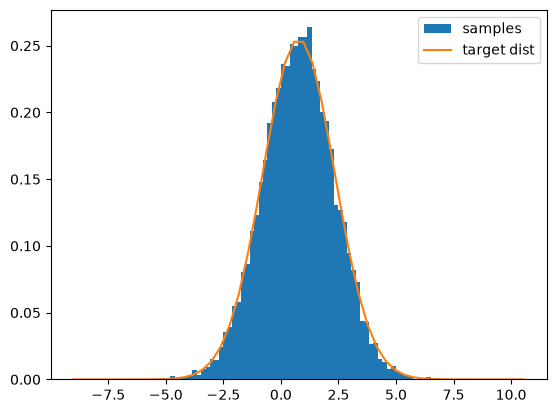

In [40]:
plot_util(samples, mean, var)

Now trying to run using mcmc for 3-dim and test


In [41]:
from scipy.stats import multivariate_normal 

tracker = AcceptanceTracker() 
dist = multivariate_normal(
    mean = target_mean, 
    cov = target_cov 
)

move_cov = np.diag([0.5, 0.5, 0.5])

def proposed_fn(st):
    return st + np.random.multivariate_normal(
        mean=np.zeros(3),
        cov = move_cov, 
    )

initial_state = np.random.uniform(0, 1, size = 3)
print(initial_state)

samples = mcmc(initial_state, dist.logpdf, proposed_fn, 200000, tracker)
print("tracker acceptance rate: {}".format(tracker.get_acceptance_rate()))
samples = np.array(samples)

mean, var, samples = test_samples(samples, target_mean, target_cov)

[0.4692269  0.63692742 0.25052317]


100%|████████████████████████| 200000/200000 [00:11<00:00, 16765.71it/s]

tracker acceptance rate: 0.2531
mean residual: 0.014911984264912036, var residual = 0.015473786338824493


Cool our samples generated by mcmc passed our test! Although the acceptance rate is not looks good (around 16%). Plotting the samples resemble the target distrib

/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_99690/3621384537.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


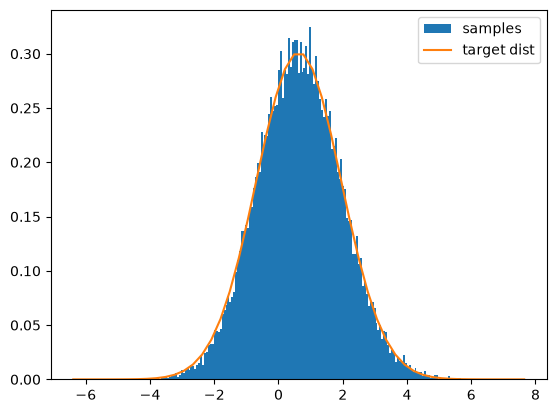

In [42]:
plot_util(samples, mean, var)

Right! Now is time to play with more high dimension 

In [49]:
DIMS = 10

In [50]:
from scipy.stats import norm 

target_mean = np.random.uniform(0, 1, size = DIMS)
K = np.random.uniform(0, 1, size = (DIMS, DIMS))
target_cov = K @ K.T 

print("target_mean: {}".format(target_mean))
print("target_cov: {}".format(target_cov))

target_mean: [0.90455107 0.47313158 0.8690134  0.85202145 0.14973032 0.03193983
 0.4050202  0.54767555 0.24805649 0.60873884]
target_cov: [[3.97743477 2.73948924 2.58625626 1.83621322 3.1612628  2.11042381
  2.27338112 2.3223327  2.90171758 3.4693695 ]
 [2.73948924 3.84824982 2.97168158 2.71736315 3.82147997 2.20393204
  2.11317933 2.36293348 3.06881336 3.98183096]
 [2.58625626 2.97168158 3.48190671 2.42643143 3.18090566 1.97901541
  1.770308   2.02870263 3.38928008 3.39277134]
 [1.83621322 2.71736315 2.42643143 2.3256737  2.80126426 1.71411284
  1.51096025 1.80337293 2.74801354 2.84237668]
 [3.1612628  3.82147997 3.18090566 2.80126426 4.23564137 2.23008717
  2.50682021 2.57575969 3.45386316 4.31829209]
 [2.11042381 2.20393204 1.97901541 1.71411284 2.23008717 2.26112315
  1.74863517 1.70527004 2.30698908 2.3683042 ]
 [2.27338112 2.11317933 1.770308   1.51096025 2.50682021 1.74863517
  2.36384043 1.53020285 1.97549531 2.78350324]
 [2.3223327  2.36293348 2.02870263 1.80337293 2.57575969 

In [51]:
import numpy as np 
from scipy.stats import multivariate_normal

tracker = AcceptanceTracker() 
dist = multivariate_normal(
    mean = target_mean, 
    cov = target_cov 
)

move_cov = np.eye(DIMS)

def proposed_fn(st):
    return st + np.random.multivariate_normal(
        mean=np.zeros(DIMS),
        cov = move_cov, 
    )

initial_state = np.random.uniform(0, 0.6, size = DIMS)

samples = mcmc(initial_state, dist.logpdf, proposed_fn, 200000, tracker)
print("tracker acceptance rate: {}".format(tracker.get_acceptance_rate()))
samples = np.array(samples)

mean, var, samples = test_samples(samples, target_mean, target_cov)

100%|████████████████████████| 200000/200000 [00:12<00:00, 16518.66it/s]

tracker acceptance rate: 0.004235
mean residual: 0.243382955489446, var residual = 0.1744174577329481


AssertionError: 

ok sadly :(  it faile with a very very very small acceptance rate. Infact, it is extremely hard to tune this rate by hand especially for high dims. From some paper, it mentioned the optimal cov tuning is something looks like 

$ 
    2.38 / DIMS * \sum_{target}
$ 

which is quite magic :) so let's try to see in case we "magically" know this move  

In [52]:
import numpy as np 
from scipy.stats import multivariate_normal

tracker = AcceptanceTracker() 
dist = multivariate_normal(
    mean = target_mean, 
    cov = target_cov 
)

move_cov = 2.38 / DIMS * target_cov

def proposed_fn(st):
    return st + np.random.multivariate_normal(
        mean=np.zeros(DIMS),
        cov = move_cov, 
    )

initial_state = np.random.uniform(0, 0.3, size = DIMS)
print(initial_state)

samples = mcmc(initial_state, dist.logpdf, proposed_fn, 200000, tracker)
print("tracker acceptance rate: {}".format(tracker.get_acceptance_rate()))
samples = np.array(samples)

mean, var, samples = test_samples(samples, target_mean, target_cov)

[0.16024854 0.23209941 0.0072195  0.22969016 0.08814955 0.24342095
 0.10383345 0.02602921 0.11314615 0.05944156]


100%|████████████████████████| 200000/200000 [00:14<00:00, 13912.26it/s]


tracker acceptance rate: 0.459335
mean residual: 0.00936086681303651, var residual = 0.018497619191855455


Wahh now the acceptance rate looks extremely good at 45%. Let's plot the samples to see how it looks

mean = 3.170307887882787, var = 112.27019222589834


/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_99690/3621384537.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


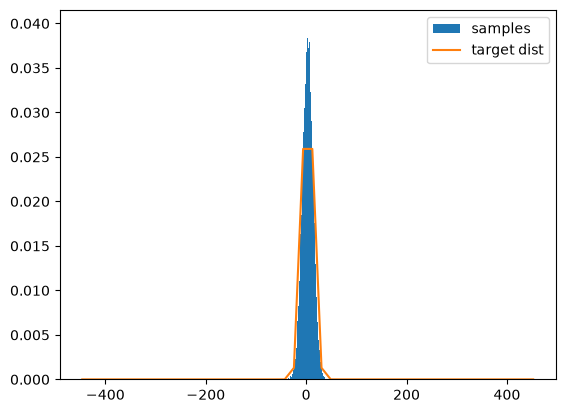

In [53]:
print("mean = {}, var = {}".format(mean, var))
plot_util(samples, mean, var)

Ok :) the interesting things to see that when dims = 10 -> even though the acceptance rate is very high but
the samples are not resemble the target distrib. With bigger DIMS, the same thing happened as the generating procedue  
overput multiple sample in the middle of the distribution.